In [1]:
# libraries
import os, sys, time
import numpy as np
import h5py
import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt

/home/yupaporn/miniconda3/envs/ns-lstm-gdm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#All climates H5 files if RAM <18 GB
#!wget https://portal.nersc.gov/project/m4134/ccai_demo.tar
#!tar -xvf ccai_demo.tar

#All climates H5 files + total precipitation if RAM > 18 GB4
# !wget https://collab.hii.or.th/s/RcrTZtXsnbjsA56/download/ccai_demo.rar
# !unrar x ccai_demo.rar

# #!rm ccai_demo.tar
# !rm ccai_demo.rar

In [3]:
# data and model paths
data_path = "./ccai_demo/data/FCN_ERA5_data_v0/out_of_sample"
data_file = os.path.join(data_path, "2018.h5")
model_path = "./ccai_demo/model_weights/FCN_weights_v0/backbone.ckpt"
global_means_path = "./ccai_demo/additional/stats_v0/global_means.npy"
global_stds_path = "./ccai_demo/additional/stats_v0/global_stds.npy"
time_means_path = "./ccai_demo/additional/stats_v0/time_means.npy"
land_sea_mask_path = "./ccai_demo/additional/stats_v0/land_sea_mask.npy"

In [4]:
# Get the model config from default configs
sys.path.insert(1, '/home/yupaporn/codes/USAI2026/NS-LSTM-GDM/FourCastNet/') # insert code repo into path
from FourCastNet.utils.YParams import YParams

In [5]:
# We are going to use a default config. Please see github repo for other config examples
config_file = "/home/yupaporn/codes/USAI2026/NS-LSTM-GDM/FourCastNet/config/AFNO.yaml"
config_name = "afno_backbone"
params = YParams(config_file, config_name)
print("Model architecture used = {}".format(params["nettype"]))

Model architecture used = afno


In [6]:
data_file

'./ccai_demo/data/FCN_ERA5_data_v0/out_of_sample/2018.h5'

Total data shape: (40, 21, 721, 1440)


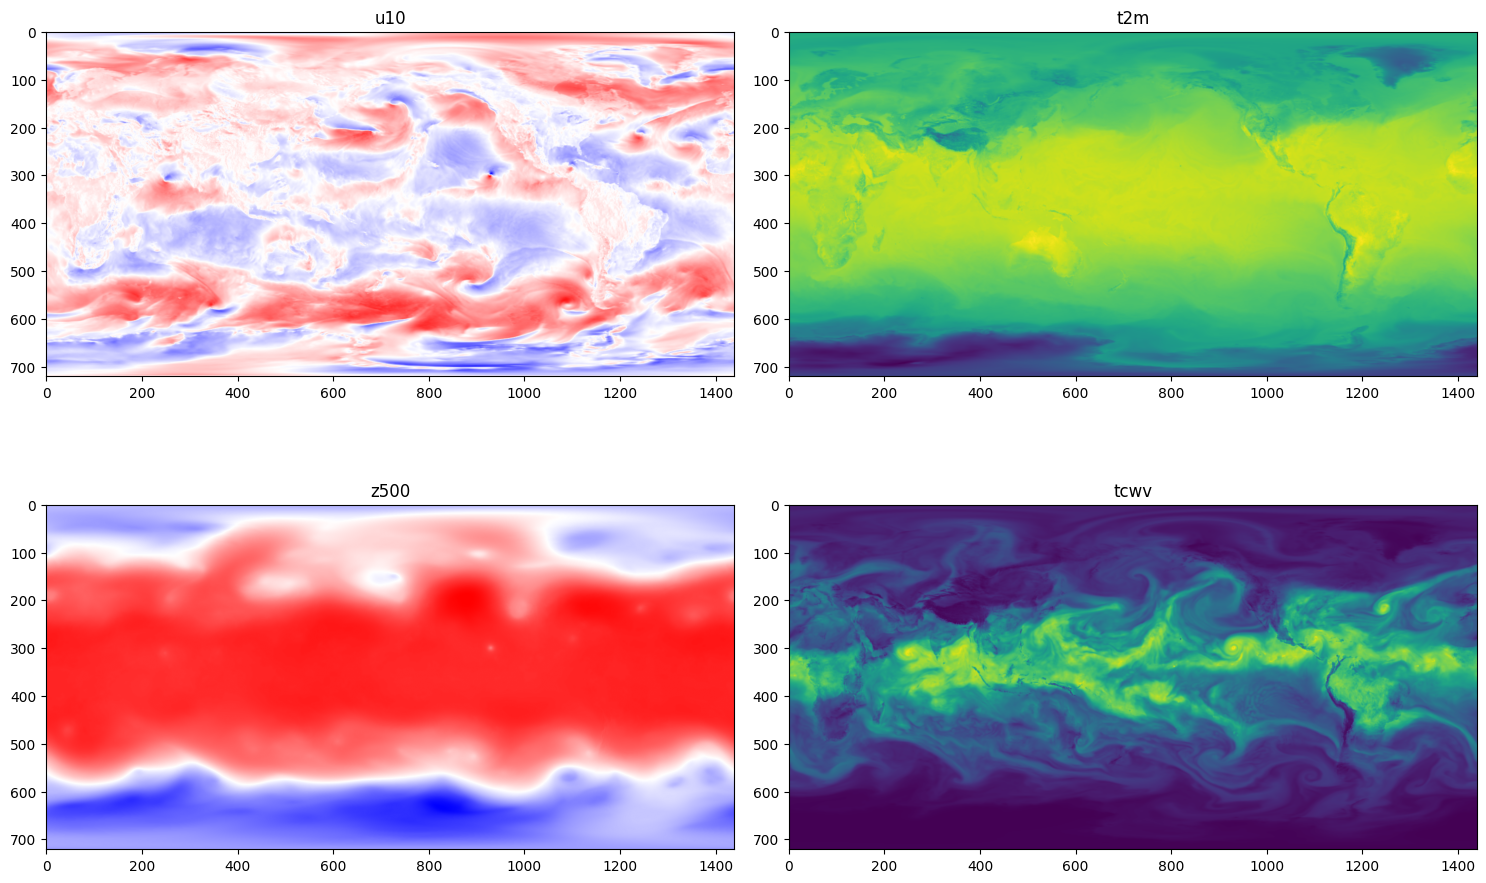

In [7]:
# '''
# The ordering of atmospheric variables along the channel dimension is as follows:
# '''
variables = ['u10',
             'v10',
             't2m',
             'sp',
             'msl',
             't850',
             'u1000',
             'v1000',
             'z1000',
             'u850',
             'v850',
             'z850',
             'u500',
             'v500',
             'z500',
             't500',
             'z50' ,
             'r500',
             'r850',
             'tcwv']

sample_data = h5py.File(data_file, 'r')['fields']
print('Total data shape:', sample_data.shape)
timestep_idx = 0
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
for i, varname in enumerate(['u10', 't2m', 'z500', 'tcwv']):
    cm = 'bwr' if varname == 'u10' or varname == 'z500' else 'viridis'
    varidx = variables.index(varname)
    ax[i//2][i%2].imshow(sample_data[timestep_idx, varidx], cmap=cm)
    ax[i//2][i%2].set_title(varname)
fig.tight_layout()

In [8]:
# import model
from networks.afnonet import AFNONet
from collections import OrderedDict

def load_model(model, params, checkpoint_file):
    ''' helper function to load model weights '''
    checkpoint_fname = checkpoint_file

    checkpoint = torch.load(checkpoint_fname , weights_only=False, map_location=torch.device('cpu') )

    try:
        ''' FourCastNet is trained with distributed data parallel
            (DDP) which prepends 'module' to all keys. Non-DDP
            models need to strip this prefix '''
        new_state_dict = OrderedDict()
        for key, val in checkpoint['model_state'].items():
            name = key[7:]
            if name != 'ged':
                new_state_dict[name] = val
        model.load_state_dict(new_state_dict)
    except:
        model.load_state_dict(checkpoint['model_state'])
    model.eval() # set to inference mode
    return model

device = torch.cuda.current_device() if torch.cuda.is_available() else 'cpu'

# in and out channels: FourCastNet uses 20 input channels corresponding to 20 prognostic variables
in_channels = np.array(params.in_channels)
out_channels = np.array(params.out_channels)
params['N_in_channels'] = len(in_channels)
params['N_out_channels'] = len(out_channels)
params.means = np.load(global_means_path)[0, out_channels] # for normalizing data with precomputed train stats
params.stds = np.load(global_stds_path)[0, out_channels]
params.time_means = np.load(time_means_path)[0, out_channels]

# load the model
if params.nettype == 'afno':
    model = AFNONet(params).to(device)  # AFNO model
else:
    raise Exception("not implemented")
# load saved model weights
model = load_model(model, params, model_path)
model = model.to(device)

In [9]:
# move normalization tensors to gpu
# load time means: represents climatology
img_shape_x = 720
img_shape_y = 1440

# means and stds over training data
means = params.means
stds = params.stds

# load climatological means
time_means = params.time_means # temporal mean (for every pixel)
m = torch.as_tensor((time_means - means)/stds)[:, 0:img_shape_x]
m = torch.unsqueeze(m, 0)
# these are needed to compute ACC and RMSE metrics
m = m.to(device, dtype=torch.float)
std = torch.as_tensor(stds[:,0,0]).to(device, dtype=torch.float)

print("Shape of time means = {}".format(m.shape))
print("Shape of std = {}".format(std.shape))

Shape of time means = torch.Size([1, 20, 720, 1440])
Shape of std = torch.Size([20])


In [10]:
# define metrics from the definitions above
def lat(j: torch.Tensor, num_lat: int) -> torch.Tensor:
    return 90. - j * 180./float(num_lat-1)

def latitude_weighting_factor(j: torch.Tensor, num_lat: int, s: torch.Tensor) -> torch.Tensor:
    return num_lat * torch.cos(3.1416/180. * lat(j, num_lat))/s

def weighted_rmse_channels(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    #takes in arrays of size [n, c, h, w]  and returns latitude-weighted rmse for each channel
    num_lat = pred.shape[2]
    lat_t = torch.arange(start=0, end=num_lat, device=pred.device)
    s = torch.sum(torch.cos(3.1416/180. * lat(lat_t, num_lat)))
    weight = torch.reshape(latitude_weighting_factor(lat_t, num_lat, s), (1, 1, -1, 1))
    result = torch.sqrt(torch.mean(weight * (pred - target)**2., dim=(-1,-2)))
    return result

def weighted_acc_channels(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    #takes in arrays of size [n, c, h, w]  and returns latitude-weighted acc for each channel
    num_lat = pred.shape[2]
    lat_t = torch.arange(start=0, end=num_lat, device=pred.device)
    s = torch.sum(torch.cos(3.1416/180. * lat(lat_t, num_lat)))
    weight = torch.reshape(latitude_weighting_factor(lat_t, num_lat, s), (1, 1, -1, 1))
    result = torch.sum(weight * pred * target, dim=(-1,-2)) / torch.sqrt(torch.sum(weight * pred * pred, dim=(-1,-2)) * torch.sum(weight * target *
    target, dim=(-1,-2)))
    return result

In [11]:
# autoregressive inference helper

def inference(data_slice, model, prediction_length, idx):
    # create memory for the different stats
    n_out_channels = params['N_out_channels']
    acc = torch.zeros((prediction_length, n_out_channels)).to(device, dtype=torch.float)
    rmse = torch.zeros((prediction_length, n_out_channels)).to(device, dtype=torch.float)

    # to conserve GPU mem, only save one channel (can be changed if sufficient GPU mem or move to CPU)
    targets = torch.zeros((prediction_length, 1, img_shape_x, img_shape_y)).to(device, dtype=torch.float)
    predictions = torch.zeros((prediction_length, 1, img_shape_x, img_shape_y)).to(device, dtype=torch.float)


    with torch.no_grad():
        for i in range(data_slice.shape[0]):
            if i == 0:
                first = data_slice[0:1]
                future = data_slice[1:2]
                pred = first
                tar = first
                # also save out predictions for visualizing channel index idx
                targets[0,0] = first[0,idx]
                predictions[0,0] = first[0,idx]
                # predict
                future_pred = model(first)
            else:
                if i < prediction_length - 1:
                    future = data_slice[i+1:i+2]
                future_pred = model(future_pred) # autoregressive step

            if i < prediction_length - 1:
                predictions[i+1,0] = future_pred[0,idx]
                targets[i+1,0] = future[0,idx]

            # compute metrics using the ground truth ERA5 data as "true" predictions
            rmse[i] = weighted_rmse_channels(pred, tar) * std
            acc[i] = weighted_acc_channels(pred-m, tar-m)
            print('Predicted timestep {} of {}. {} RMS Error: {}, ACC: {}'.format(i, prediction_length, field, rmse[i,idx], acc[i,idx]))

            pred = future_pred
            tar = future

    # copy to cpu for plotting/vis
    acc_cpu = acc.cpu().numpy()
    rmse_cpu = rmse.cpu().numpy()
    predictions_cpu = predictions.cpu().numpy()
    targets_cpu = targets.cpu().numpy()

    return acc_cpu, rmse_cpu, predictions_cpu, targets_cpu


In [36]:
# setup data for inference
dt = 1 # time step (x 6 hours)
ic = 0 # start the inference from here
prediction_length = 10 # number of steps (x 6 hours)

# which field to track for visualization
field = 'u10'
idx_vis = variables.index(field) # also prints out metrics for this field

# get prediction length slice from the data
print('Loading inference data')
print('Inference data from {}'.format(data_file))
data = h5py.File(data_file, 'r')['fields'][ic:(ic+prediction_length*dt):dt,in_channels,0:img_shape_x]
print(data.shape)
print("Shape of data = {}".format(data.shape))

Loading inference data
Inference data from ./ccai_demo/data/FCN_ERA5_data_v0/out_of_sample/2018.h5
(10, 20, 720, 1440)
Shape of data = (10, 20, 720, 1440)


In [37]:
# run inference
data = (data - means)/stds # standardize the data
data = torch.as_tensor(data).to(device, dtype=torch.float) # move to gpu for inference
acc_cpu, rmse_cpu, predictions_cpu, targets_cpu = inference(data, model, prediction_length, idx=idx_vis)

Predicted timestep 0 of 10. u10 RMS Error: 0.0, ACC: 1.0
Predicted timestep 1 of 10. u10 RMS Error: 0.5595946907997131, ACC: 0.9900789260864258
Predicted timestep 2 of 10. u10 RMS Error: 0.7682855725288391, ACC: 0.9802855253219604
Predicted timestep 3 of 10. u10 RMS Error: 0.8545154333114624, ACC: 0.9751376509666443
Predicted timestep 4 of 10. u10 RMS Error: 0.9780223965644836, ACC: 0.9663249850273132
Predicted timestep 5 of 10. u10 RMS Error: 1.0724455118179321, ACC: 0.9600211977958679
Predicted timestep 6 of 10. u10 RMS Error: 1.2340999841690063, ACC: 0.9463505744934082
Predicted timestep 7 of 10. u10 RMS Error: 1.3775665760040283, ACC: 0.934525191783905
Predicted timestep 8 of 10. u10 RMS Error: 1.5805351734161377, ACC: 0.9138075709342957
Predicted timestep 9 of 10. u10 RMS Error: 1.7355377674102783, ACC: 0.9003415107727051


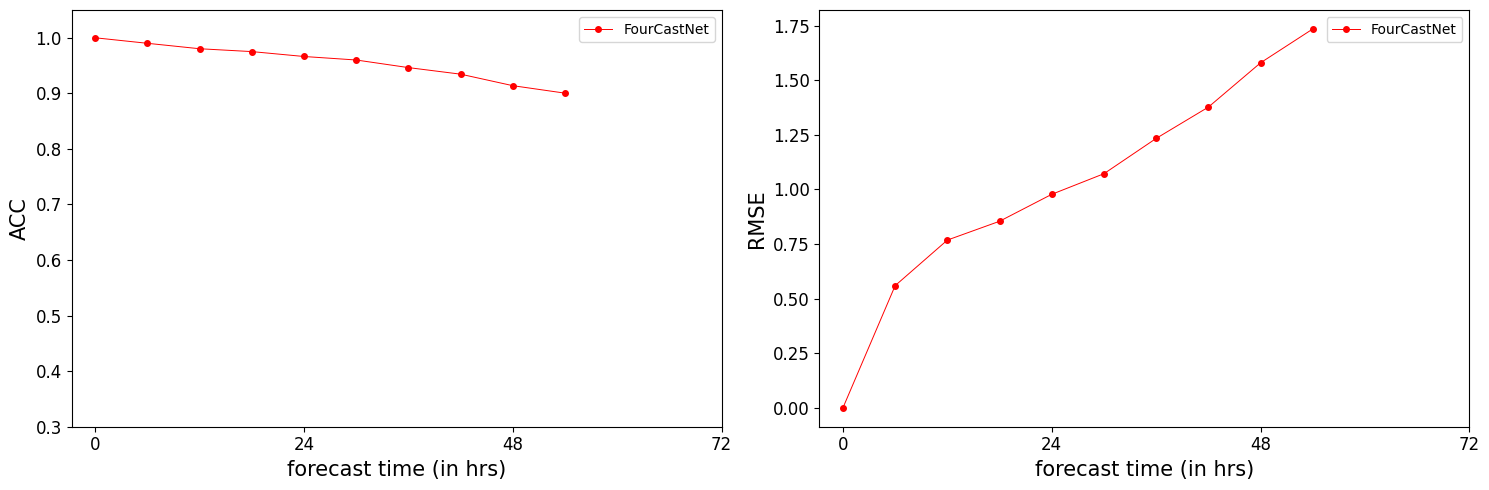

In [38]:
# plot the acc and rmse metrics
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
start = 0
end = prediction_length #  < prediction_lenght forecast

field = 'u10' # change this to other fields such as z500
idx_metric = variables.index(field) # plot metrics for this field

hrs = np.arange(0, end*6, 6)
ax[0].plot(hrs, acc_cpu[start:end,idx_metric], "o-", label="FourCastNet", ms=4, lw=0.7, color="r")
ax[1].plot(hrs, rmse_cpu[start:end,idx_metric], "o-", label="FourCastNet", ms=4, lw=0.7, color="r")
ax[0].legend()
ax[1].legend()
fsz = "15"
xlist = np.arange(0,end*6+24,24)
ax[0].set_xlabel("forecast time (in hrs)", fontsize=fsz)
ax[1].set_xlabel("forecast time (in hrs)", fontsize=fsz)
ax[0].set_ylabel("ACC", fontsize=fsz)
ax[1].set_ylabel("RMSE", fontsize=fsz)
ax[0].set_ylim(0.3, 1.05)
ax[0].set_xticks(xlist)
ax[1].set_xticks(xlist)
ax[0].tick_params(axis='both', which='both', labelsize=12)
ax[1].tick_params(axis='both', which='both', labelsize=12)
fig.tight_layout()

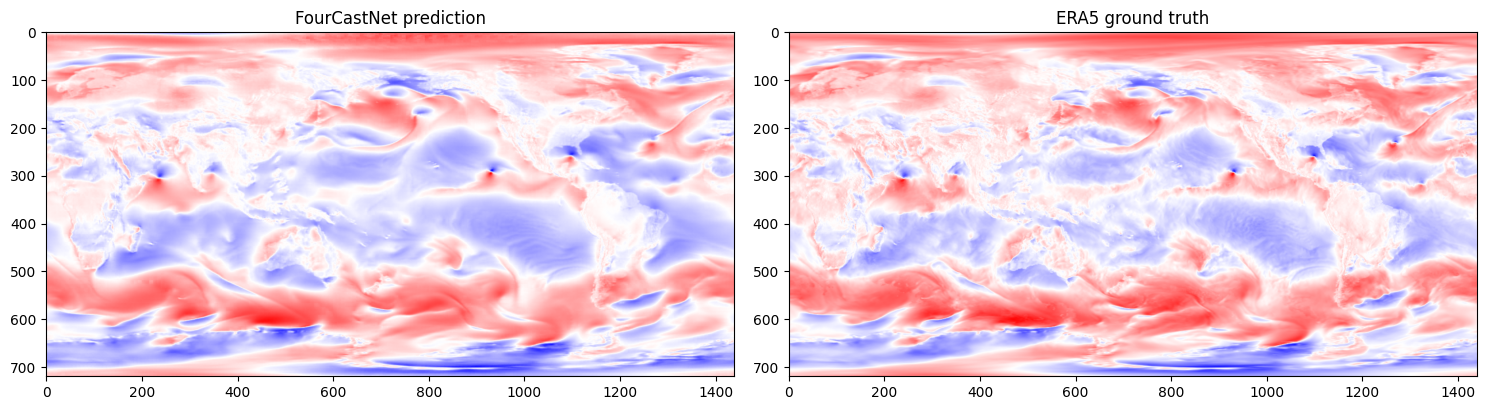

In [39]:
# visualize spatiotemporal predictions
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
t = 6 # at 2x6 hours lead time
ax[0].imshow(predictions_cpu[t,0], cmap="bwr")
ax[1].imshow(targets_cpu[t,0], cmap="bwr")
ax[0].set_title("FourCastNet prediction")
ax[1].set_title("ERA5 ground truth")
fig.tight_layout()

In [40]:
def quantiles(x, qtile):
    ''' helper to compute quantiles based on qtile of the field '''
    n, c, h, w = x.shape
    return np.quantile(x.reshape((n,c,h*w)), q=qtile, axis=-1).squeeze()

In [41]:
qs = 100
qlim = 4
qcut = 1
qtile = 1. - np.logspace(-qlim, -qcut, num=qs) # log-spaced bins for quantiles

# compute quantiles for the fields saved (channel idx_vis is saved out now)
era5_q = quantiles(targets_cpu, qtile)
mean_era5 = era5_q.mean(axis=1) # stats over different time points
std_era5 = era5_q.std(axis=1)

pred_q = quantiles(predictions_cpu, qtile) # for predictions
mean_pred = pred_q.mean(axis=1)
std_pred = pred_q.std(axis=1)

print(era5_q.shape, pred_q.shape)

(100, 10) (100, 10)


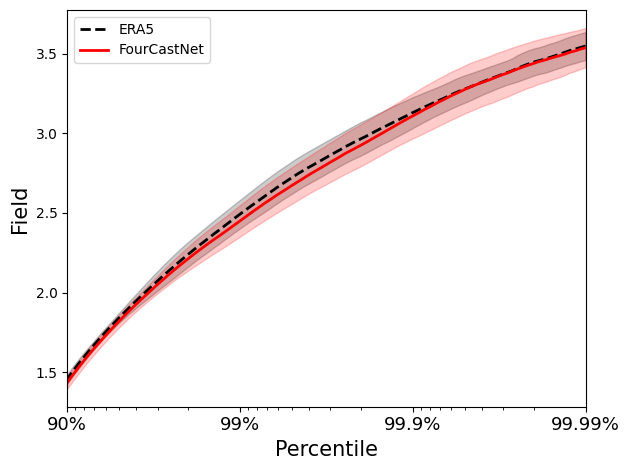

In [42]:
# plot the extremes
plt.figure()
fs=15
ax = plt.gca() #axs[0]
qtiles = np.logspace(-qlim, -qcut, num=qs)
ax.plot(qtiles, mean_era5, 'k--', label='ERA5', lw=2)
ax.fill_between(qtiles, mean_era5+std_era5, mean_era5-std_era5, alpha=0.2, color='k')
ax.plot(qtiles, mean_pred, 'r-', label='FourCastNet', lw=2)
ax.fill_between(qtiles, mean_pred+std_pred, mean_pred-std_pred, alpha=0.2, color='r')
ax.set_xlim((qtiles[-1], qtiles[0]))
ax.set_xscale('log')
ax.set_xticks(ticks=10.**np.arange(-1,-qlim - 1, -1))
ax.set_xticklabels(labels=['%g%%'%(100.*(1. - 10.**q)) for q in np.arange(-1,-qlim - 1, -1)], fontsize=fs-2)
ax.set_xlabel('Percentile', fontsize=fs)
ax.set_ylabel('Field', fontsize=fs)
ax.legend()
plt.tight_layout()

In [43]:
# which field to track for visualization
field = 'msl' # mean surface level pressure
idx_vis = variables.index(field) # also prints out metrics for this field

acc_cpu_msl, rmse_cpu_msl, predictions_cpu_msl, targets_cpu_msl = inference(data, model, prediction_length, idx=idx_vis)

# destandardize the fields for msl
m_msl = params.means[idx_vis,0]
s_msl = params.stds[idx_vis,0]

pred_msl = s_msl*predictions_cpu_msl + m_msl
true_msl = s_msl*targets_cpu_msl + m_msl
print(pred_msl.shape, true_msl.shape) # destandardized forecasted and true msl fields

Predicted timestep 0 of 10. msl RMS Error: 0.0, ACC: 1.0
Predicted timestep 1 of 10. msl RMS Error: 38.01778793334961, ACC: 0.9986559152603149
Predicted timestep 2 of 10. msl RMS Error: 55.31367111206055, ACC: 0.9970651268959045
Predicted timestep 3 of 10. msl RMS Error: 61.87912368774414, ACC: 0.9964413046836853
Predicted timestep 4 of 10. msl RMS Error: 77.74364471435547, ACC: 0.9944821000099182
Predicted timestep 5 of 10. msl RMS Error: 87.43633270263672, ACC: 0.9927592873573303
Predicted timestep 6 of 10. msl RMS Error: 107.86070251464844, ACC: 0.9885033369064331
Predicted timestep 7 of 10. msl RMS Error: 125.31645965576172, ACC: 0.9848662614822388
Predicted timestep 8 of 10. msl RMS Error: 147.39898681640625, ACC: 0.9790378212928772
Predicted timestep 9 of 10. msl RMS Error: 173.3444061279297, ACC: 0.9707462191581726
(10, 1, 720, 1440) (10, 1, 720, 1440)


In [47]:
# focus on this region: represents hurricane Michael focus
x_min = 1081
x_max = 1121
y_min = 201
y_max = 305

track_pred_x = []
track_pred_y = []
track_true_x = []
track_true_y = []


# t_max = 14 # number of time steps to track the hurricane (roughly the number of steps to reach landfall)
t_max = min(14, pred_msl.shape[0])
timeaxis = np.arange(0,t_max)

for t in range(t_max):
  min_pressure_predicted = np.min(pred_msl[t,0,y_min:y_max,x_min:x_max])
  pred_y = np.where(pred_msl[t,0,y_min:y_max, x_min:x_max] == min_pressure_predicted)[0]
  pred_x = np.where(pred_msl[t,0,y_min:y_max, x_min:x_max] == min_pressure_predicted)[1]
  track_pred_x.append(pred_x[0])
  track_pred_y.append(pred_y[0])


  min_pressure_true = np.min(true_msl[t,0,y_min:y_max,x_min:x_max])
  true_y = np.where(true_msl[t,0,y_min:y_max, x_min:x_max] == min_pressure_true)[0]
  true_x = np.where(true_msl[t,0,y_min:y_max, x_min:x_max] == min_pressure_true)[1]
  track_true_x.append(true_x[0])
  track_true_y.append(true_y[0])

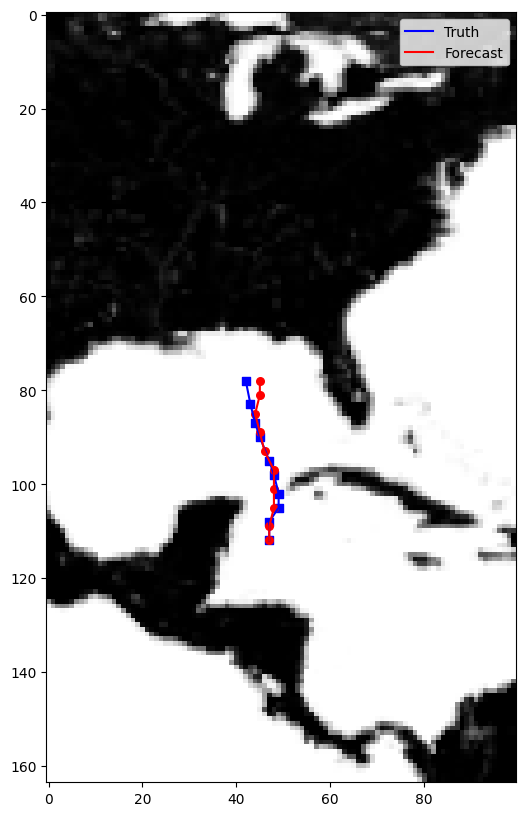

In [48]:
offset = 30
lsm = np.load(land_sea_mask_path)[0:720] # land-sea mask to show coastlines
plt.figure(figsize=(30, 10))
ax = plt.gca()
ax.imshow(lsm[y_min-offset:y_max+offset, x_min-offset:x_max+offset], cmap = 'Greys')
plt.scatter(np.array(track_true_x) + offset , np.array(track_true_y) + offset, s = 30, marker = 's', c = 'b')
plt.plot(np.array(track_true_x) + offset , np.array(track_true_y) + offset, c = 'b', label="Truth")
plt.scatter(np.array(track_pred_x) + offset , np.array(track_pred_y) + offset, s = 30, marker = 'o', c = 'r')
plt.plot(np.array(track_pred_x) + offset , np.array(track_pred_y) + offset, c = 'r', label="Forecast")
plt.legend()